# Paper figures

Generates every figure for the writeup of *Cross-modal information flow in LLaVA-v1.5-7b*.

All numbers come from committed `*.summary.json` files. No experiment is run, no raw
(gitignored) result file is read, and nothing under `sae_experiments/` is touched.
Figures are written to `output/paper_figures/` at 300 dpi.

Run the **Setup** cell once; after that every figure cell runs independently.

## Source-file notes

A few things about the source paths are worth stating up front, because the filenames are
not consistent across layers:

- **Layer 11** has two runs. `results/ablation_results.summary.json` is the n=256 headline run
  and the one used here. `results/ablation_v2_results.summary.json` is an n=50 run — not used.
- **Layer 14** was run on 2026-08-06, after `LLM_TECHNICAL_SUMMARY.md` was last written; that
  document still lists it as "not run". Its summary was distilled with
  `tools/distill_results.py` and lives at `results/ablation_v2_results.summary.json`.
- **Layer 10** also has two runs, and this is the one that trips people up. The technical
  summary's prose mentions the nested path `results/ablation_v2/ablation_v2_results.json`,
  but the numbers it actually reports (0.15141, z=66.5, 81.2% positive) come from the *flat*
  `results/ablation_results.summary.json` — which is what `LLM_TECHNICAL_SUMMARY.json`
  records under `layers.10.ablation_v2.source`. The nested file is a different run of the
  same config (0.15097, z=56.2, 82.0% positive). This notebook uses the flat file, and the
  figure-2 cell prints both so the difference stays visible.
- **The multi-layer run** (figures 6-9) is one directory,
  `multilayer_clevr_lite_l10-14_attn_out_question/`: 47 condition summaries under
  `conditions/<id>/summary.json`, plus `analysis/multilayer_summary.json`. Read the
  `summary.json` — the runner's `results.json` beside it is gitignored. Every condition is
  n=256 over the same question set, and unlike the per-layer runs its random controls are
  *matched* on `activation_mean` rather than uniform. Figure 9 is that difference, measured.

## One number here disagrees with the technical summary

`LLM_TECHNICAL_SUMMARY.md` states there is **zero overlap** between the v1 and v2 top-200
feature sets. The committed catalogs give an overlap of **2** (features 18443 and 20629).
Figure 4 prints the computed value, not the summary's. See that cell for the full caveat —
the two SAEs are different dictionaries, so the overlap is close to meaningless either way,
but it is not zero.

## Setup

Paths, palette and matplotlib defaults. Every figure cell below depends only on this cell.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path("..").resolve()
SAE = REPO / "output/sae_experiments"
FIGDIR = REPO / "output/paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-2 plus chart ink, from the validated reference palette.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
CRIT = "#d03b3b"
INK = "#0b0b0b"
SECOND = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#ffffff"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.labelcolor": INK,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
})


def tidy(ax):
    """Recessive grid and axes: drop the top/right spines, put the grid behind the marks."""
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)



# The multi-layer run behind figures 6-9: 47 conditions, all n=256 on one question set.
ML = SAE / "multilayer_clevr_lite_l10-14_attn_out_question"
ANALYSIS = json.load(open(ML / "analysis/multilayer_summary.json"))


def cond(name):
    """One multi-layer condition summary (the runner's results.json minus per_sample)."""
    return json.load(open(ML / "conditions" / name / "summary.json"))


def drop(name):
    return cond(name)["summary"]["mean_margin_drop"]


def perturb(name):
    return cond(name)["summary"]["mean_relative_perturbation"]


print("repo :", REPO)
print("figs :", FIGDIR)
print("multi:", ANALYSIS["n_conditions"], "conditions over layers", ANALYSIS["span"])

repo : /home/ron/Documents/Github/cross-modal-information-flow-in-MLLM
figs : /home/ron/Documents/Github/cross-modal-information-flow-in-MLLM/output/paper_figures
multi: 47 conditions over layers [10, 11, 12, 13, 14]


---

### Figure 1 — Attention-knockout landscape

Blocking the `Image->Question` attention flow one layer at a time reveals three regions: a
strong early site at layer 0, a mid-network cluster at layers 10-14, and late-layer
inhibition where blocking the flow slightly *improves* the margin. The `Image->Last` flow is
an order of magnitude weaker everywhere. Caveat: the negative drops at layers 13, 26 and 29
are real signal, not bugs, and all 64 points are n=7084 with p < 1e-10.

In [ ]:
ko = json.load(open(SAE / "exp_default/knockout/knockout_summary.json"))

question = sorted([r for r in ko if r["flow"] == "Image->Question"], key=lambda r: r["layer"])
last = sorted([r for r in ko if r["flow"] == "Image->Last"], key=lambda r: r["layer"])

layers = [r["layer"] for r in question]
q_drop = [r["mean_margin_drop"] for r in question]
q_d = [r["effect_size"] for r in question]
l_drop = [r["mean_margin_drop"] for r in last]
l_d = [r["effect_size"] for r in last]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7.2), sharex=True,
                               gridspec_kw={"hspace": 0.18})

for ax in (ax1, ax2):
    ax.axvspan(9.5, 14.5, color=BLUE, alpha=0.07, lw=0, zorder=0)
    ax.axhline(0, color=BASELINE, lw=1.2, zorder=1)
    tidy(ax)

ax1.plot(layers, q_drop, color=BLUE, lw=2, marker="o", ms=4.5, label="Image->Question", zorder=3)
ax1.plot(layers, l_drop, color=ORANGE, lw=2, marker="o", ms=4.5, label="Image->Last", zorder=3)
ax2.plot(layers, q_d, color=BLUE, lw=2, marker="o", ms=4.5, label="Image->Question", zorder=3)
ax2.plot(layers, l_d, color=ORANGE, lw=2, marker="o", ms=4.5, label="Image->Last", zorder=3)

# The three negative Image->Question drops called out in the writeup.
for L in (13, 26, 29):
    ax1.plot(L, q_drop[L], marker="o", ms=11, mfc="none", mec=CRIT, mew=1.8, zorder=4)
    ax2.plot(L, q_d[L], marker="o", ms=11, mfc="none", mec=CRIT, mew=1.8, zorder=4)

ax1.annotate("layer 0\n0.457", xy=(0, q_drop[0]), xytext=(2.4, 0.44),
             color=INK, fontsize=9, va="center",
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax1.text(12, 0.50, "layers 10-14", color=BLUE, fontsize=9, ha="center", fontweight="bold")
ax1.annotate("inhibitory: blocking helps", xy=(13, q_drop[13]), xytext=(18.5, -0.128),
             color=CRIT, fontsize=9, ha="center",
             arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))
for L in (26, 29):
    ax1.plot([L, L], [q_drop[L] - 0.012, -0.10], color=CRIT, lw=1, zorder=2)
ax1.text(27.5, -0.128, "also inhibitory", color=CRIT, fontsize=9, ha="center", va="center")

ax1.set_ylabel("mean margin drop")
ax1.set_ylim(-0.16, 0.56)
ax1.legend(loc="upper right", ncol=2)

ax2.set_ylabel("effect size (Cohen's d)")
ax2.set_xlabel("layer")
ax2.set_ylim(-1.45, 1.45)
ax2.set_xticks(range(0, 32, 2))
ax2.set_xlim(-1, 32)
ax2.legend(loc="lower left", ncol=2)

fig.savefig(FIGDIR / "fig1_knockout_landscape.png")
plt.show()

print("Image->Question, n =", question[0]["samples"], "per layer")
for L in (0, 10, 11, 12, 13, 14, 26, 29):
    r = question[L]
    print("  layer %2d  drop %+.4f  d %+.3f  p %.3g" % (L, r["mean_margin_drop"], r["effect_size"], r["p_value"]))
print()
print("Image->Question layers with a negative drop:",
      [r["layer"] for r in question if r["mean_margin_drop"] < 0])
print("Image->Last  max drop %.4f (layer %d)  vs  Image->Question max %.4f (layer %d)"
      % (max(l_drop), int(np.argmax(l_drop)), max(q_drop), int(np.argmax(q_drop))))

---

### Figure 2 — SAE feature ablation against random controls

**Caveat that governs this whole figure: the controls are uniform draws, not matched.** The
configs request matching on `correct_mean`, a key absent from every v2 stats file, so the
sampler silently fell back to uniform — at layer 11 the controls have median activation 6.1e-08
against the binding set's 0.117. The separation shown here is therefore against near-dead
features and the z-scores are inflated by an unknown amount; the margin drops and the per-sample
positive fractions are unaffected. Re-runs with matched controls are pending.

Ablating the top-200 causally-identified features moves the margin far outside the spread of
15 random control sets at every layer tested: **layer 14 gives the largest drop**
(0.2433, with 90.2% of samples positive) while **layer 11 gives the largest separation from
its controls** (z = 81.6 vs 70.0, because layer 14's control sets are noisier — sd 0.00347 vs
0.00261). Caveat: **layer 0's SAE has a dead-feature fraction of 0.742** — 74% of its 32768
features never activate, against 0.06-0.4% elsewhere — so its small effect (0.0200) measures
a failed dictionary, not the absence of sparsely encoded visual information at that layer.

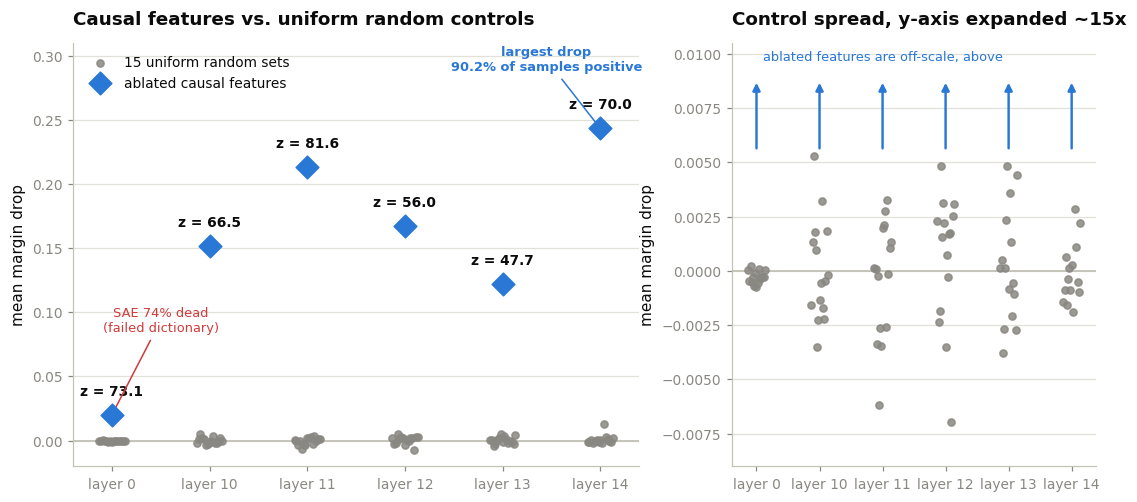

layer   ablated   ctrl mean (sd)        z      %pos   flips c->w
   0    0.0200   -0.00028 (0.00028)    73.1   56.6%   0
  10    0.1514   +0.00004 (0.00228)    66.5   81.2%   3
  11    0.2131   -0.00039 (0.00261)    81.6   84.8%   4
  12    0.1670   +0.00059 (0.00297)    56.0   82.8%   3
  13    0.1220   +0.00023 (0.00255)    47.7   64.8%   3
  14    0.2433   +0.00076 (0.00347)    70.0   90.2%   2

largest drop:      layer 14 (0.2433)
largest z:         layer 11 (81.6)
most % positive:   layer 14 (90.2%)

layer 11 source: output/sae_experiments/sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json
layer 10 source: output/sae_experiments/sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json
layer 10 has a second run at results/ablation_v2/ablation_v2_results.summary.json:
   that file: 0.15097 (z = 56.2)   |   file used here: 0.15141 (z = 66.5)
   the technical summary reports the second of these; see the notes at the top.


In [3]:
ablation_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/results/ablation_v2_results.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/results/ablation_v2_results.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/results/ablation_v2_results.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/results/ablation_v2_results.summary.json",
}

layers = [0, 10, 11, 12, 13, 14]
binding, rand_sets, zs, fracpos, flips = [], [], [], [], []
for L in layers:
    d = json.load(open(ablation_paths[L]))
    sig = d["significance"]["mean_margin_drop"]
    binding.append(sig["binding"])
    zs.append(sig["z_score"])
    rand_sets.append([s["mean_margin_drop"] for s in d["random_set_summaries"]])
    fracpos.append(d["binding_results"]["field_summaries"]["margin_drop"]["frac_positive"])
    flips.append(d["binding_results_prediction_changes"]["correct_to_wrong"])

x = np.arange(len(layers))
jitter = np.linspace(-0.13, 0.13, 15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.55, 1]})

for i in range(len(layers)):
    ax1.scatter(x[i] + jitter, rand_sets[i], s=22, color=MUTED, alpha=0.85, zorder=3,
                label="15 uniform random sets" if i == 0 else None)
ax1.scatter(x, binding, s=110, marker="D", color=BLUE, zorder=4, label="ablated causal features")
for i in range(len(layers)):
    ax1.annotate("z = %.1f" % zs[i], xy=(x[i], binding[i]), xytext=(0, 13),
                 textcoords="offset points", ha="center", fontsize=9,
                 color=INK, fontweight="bold")
ax1.axhline(0, color=BASELINE, lw=1.2, zorder=1)
ax1.set_xticks(x)
ax1.set_xticklabels(["layer %d" % L for L in layers])
ax1.set_ylabel("mean margin drop")
ax1.set_ylim(-0.02, 0.31)
ax1.set_title("Causal features vs. uniform random controls", loc="left", pad=12)
ax1.legend(loc="upper left")
tidy(ax1)
ax1.annotate("SAE 74% dead\n(failed dictionary)", xy=(0, binding[0]), xytext=(0.5, 0.085),
             color=CRIT, fontsize=8.5, ha="center",
             arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))

top = int(np.argmax(binding))
ax1.annotate("largest drop\n%.1f%% of samples positive" % (fracpos[top] * 100),
             xy=(x[top], binding[top]), xytext=(x[top] - 0.55, binding[top] + 0.045),
             color=BLUE, fontsize=8.5, ha="center", fontweight="bold",
             arrowprops=dict(arrowstyle="-", color=BLUE, lw=1))

for i in range(len(layers)):
    ax2.scatter(x[i] + jitter, rand_sets[i], s=22, color=MUTED, alpha=0.85, zorder=3)
    ax2.annotate("", xy=(x[i], 0.0088), xytext=(x[i], 0.0055),
                 arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=1.6))
ax2.axhline(0, color=BASELINE, lw=1.2, zorder=1)
ax2.set_xticks(x)
ax2.set_xticklabels(["layer %d" % L for L in layers])
ax2.set_ylim(-0.009, 0.0105)
ax2.set_ylabel("mean margin drop")
ax2.set_title("Control spread, y-axis expanded ~15x", loc="left", pad=12)
ax2.text(2, 0.0097, "ablated features are off-scale, above", color=BLUE, fontsize=8.5, ha="center")
tidy(ax2)

fig.savefig(FIGDIR / "fig2_ablation_vs_controls.png")
plt.show()

print("layer   ablated   ctrl mean (sd)        z      %pos   flips c->w")
for i, L in enumerate(layers):
    print("  %2d    %.4f   %+.5f (%.5f)   %5.1f   %.1f%%   %d"
          % (L, binding[i], np.mean(rand_sets[i]), np.std(rand_sets[i], ddof=0),
             zs[i], fracpos[i] * 100, flips[i]))
print()
print("largest drop:      layer %d (%.4f)" % (layers[int(np.argmax(binding))], max(binding)))
print("largest z:         layer %d (%.1f)" % (layers[int(np.argmax(zs))], max(zs)))
print("most %% positive:   layer %d (%.1f%%)" % (layers[int(np.argmax(fracpos))], max(fracpos) * 100))
print()
print("layer 11 source:", ablation_paths[11].relative_to(REPO))
print("layer 10 source:", ablation_paths[10].relative_to(REPO))

nested10 = SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_v2/ablation_v2_results.summary.json"
alt = json.load(open(nested10))["significance"]["mean_margin_drop"]
print("layer 10 has a second run at results/ablation_v2/ablation_v2_results.summary.json:")
print("   that file: %.5f (z = %.1f)   |   file used here: %.5f (z = %.1f)"
      % (alt["binding"], alt["z_score"], binding[1], zs[1]))
print("   the technical summary reports the second of these; see the notes at the top.")

---

### Figure 3 — Ablation as a fraction of the knockout ceiling

Knockout removes the whole `Image->Question` flow at a layer, so its margin drop is the
natural ceiling for what feature ablation at the same layer can recover; across the mid-network
cluster 200 features capture 50-68% of it. Caveat: **layer 13 is excluded rather than
plotted** — its knockout drop is negative (-0.0483), so the ratio is undefined, and layer 0's
4.4% reflects its failed SAE (74% dead features) rather than a property of the layer.

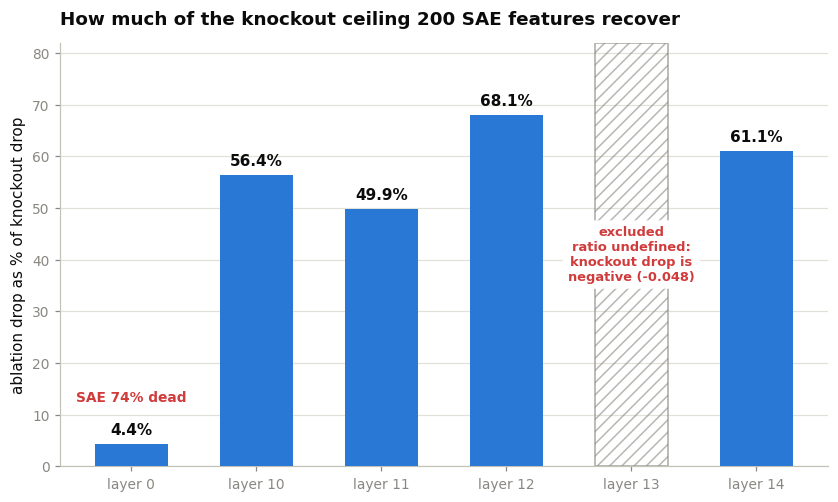

layer   ablation   knockout   % of ceiling
   0     0.0200     0.4575      4.4%
  10     0.1514     0.2683      56.4%
  11     0.2131     0.4273      49.9%
  12     0.1670     0.2452      68.1%
  13     0.1220    -0.0483      undefined (knockout drop is negative)
  14     0.2433     0.3983      61.1%


In [4]:
ko = json.load(open(SAE / "exp_default/knockout/knockout_summary.json"))
knockout_q = {r["layer"]: r["mean_margin_drop"] for r in ko if r["flow"] == "Image->Question"}

ablation_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/results/ablation_v2_results.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/results/ablation_v2_results.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/results/ablation_v2_results.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/results/ablation_v2_results.summary.json",
}

ablated = {L: json.load(open(p))["significance"]["mean_margin_drop"]["binding"]
           for L, p in ablation_paths.items()}

# Layer 13's knockout drop is negative, so the ratio is undefined and it is marked, not plotted.
layers = [0, 10, 11, 12, 13, 14]
excluded = 13

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(layers))

TOP = 82

for xi, L in zip(x, layers):
    if L == excluded:
        # Full-height hatch, so the excluded layer cannot be misread as a bar of some value.
        ax.bar(xi, TOP, width=0.58, facecolor="none", edgecolor=MUTED, hatch="///", lw=1.2,
               alpha=0.6, zorder=2)
        ax.text(xi, TOP / 2, "excluded\nratio undefined:\nknockout drop is\nnegative (-0.048)",
                ha="center", va="center", fontsize=8.5, color=CRIT, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor="none"))
        continue
    p = 100 * ablated[L] / knockout_q[L]
    ax.bar(xi, p, width=0.58, color=BLUE, zorder=3)
    ax.text(xi, p + 1.8, "%.1f%%" % p, ha="center", fontsize=10, fontweight="bold", color=INK)

ax.set_xticks(x)
ax.set_xticklabels(["layer %d" % L for L in layers])
ax.set_ylabel("ablation drop as % of knockout drop")
ax.set_ylim(0, TOP)
ax.set_title("How much of the knockout ceiling 200 SAE features recover", loc="left", pad=12)
tidy(ax)
ax.text(0, 100 * ablated[0] / knockout_q[0] + 8.2, "SAE 74% dead",
        color=CRIT, fontsize=9, ha="center", fontweight="bold")

fig.savefig(FIGDIR / "fig3_fraction_of_ceiling.png")
plt.show()

print("layer   ablation   knockout   % of ceiling")
for L in layers:
    if L == excluded:
        print("  %2d     %.4f    %+.4f      undefined (knockout drop is negative)"
              % (L, ablated[L], knockout_q[L]))
    else:
        print("  %2d     %.4f     %.4f      %.1f%%"
              % (L, ablated[L], knockout_q[L], 100 * ablated[L] / knockout_q[L]))

---

### Figure 4 — Why the v1 feature-selection metric produced 18 null results

v1 scored features by the ratio of mean activation on correct vs. incorrect samples, a metric
maximised by features that barely activate; its top-500 sit ~70x below the top-500 that v2's
gradient attribution selects, which is why ablating them changed nothing.
Caveat: these are **different dictionaries, not a matched ablation** — v1 (`sae_q_layer11`)
was trained on GQA at the residual site with `attribute` positions and only 14,914 of its
32,768 features ever activated, against CLEVR-Lite / `attn_out` / `question` positions for
v2, so the figure is evidence about the *selection metric*, not about a like-for-like
comparison of the two feature sets.

In [ ]:
# Like-for-like comparison: both rankings come from the SAME dictionary --
# CLEVR-Lite, layer 11, attn_out, question positions. (sae_q_layer11/ is the
# GQA-era v1 run at a different layer, site and position set; ranking it against
# the CLEVR-Lite v2 catalog compares two unrelated experiments.)
v1 = json.load(open(SAE / "sae_clevr_lite_layer11_attn_out_question/feature_stats.summary.json"))
v2 = json.load(open(SAE / "sae_clevr_lite_layer11_attn_out_question_causal/causal_feature_stats.summary.json"))

TOP = 200  # the ablated set size the paper reports
v1_act = np.array([f["correct_mean"] for f in v1["top_features"]][:TOP])
v2_act = np.array([f["activation_mean"] for f in v2["top_features"]][:TOP])
m1, m2 = np.median(v1_act), np.median(v2_act)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bins = np.logspace(-7.0, 0.2, 60)

ax.hist(v1_act, bins=bins, color=ORANGE, alpha=0.85, zorder=3,
        label="v1 top-%d, ranked by activation ratio" % TOP)
ax.hist(v2_act, bins=bins, color=BLUE, alpha=0.85, zorder=3,
        label=r"v2 top-%d, ranked by |grad| $\times$ |activation|" % TOP)

ax.axvline(m1, color=ORANGE, lw=1.5, ls="--", zorder=4)
ax.axvline(m2, color=BLUE, lw=1.5, ls="--", zorder=4)
ax.text(m1 * 1.7, 70, "median %.1e" % m1, color=ORANGE, fontsize=9.5, fontweight="bold", va="center")
ax.text(m2 * 1.7, 70, "median %.3f" % m2, color=BLUE, fontsize=9.5, fontweight="bold", va="center")

ax.annotate("", xy=(m2, 40), xytext=(m1, 40),
            arrowprops=dict(arrowstyle="<->", color=SECOND, lw=1.3))
ax.text(np.sqrt(m1 * m2), 45, "%.0f orders of magnitude apart" % round(np.log10(m2 / m1)),
        color=SECOND, fontsize=10, fontweight="bold", ha="center")
ax.text(np.sqrt(m1 * m2), 26, "zero features in common", color=SECOND, fontsize=9,
        ha="center", style="italic")

ax.set_xscale("log")
ax.set_xlim(3e-8, 4)
ax.set_ylim(0, 92)
ax.set_xlabel("mean activation magnitude of the selected feature (log scale)")
ax.set_ylabel("features")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02))
tidy(ax)

fig.savefig(FIGDIR / "fig4_v1_ghost_features.png")
plt.show()

top_v1 = set(f["feature"] for f in v1["top_features"][:TOP])
top_v2 = set(f["feature"] for f in v2["top_features"][:TOP])
n_zero = sum(1 for f in v1["top_features"][:TOP] if f["incorrect_mean"] == 0.0)

print("v1 top-%d activation: median %.4g  mean %.4g" % (TOP, m1, v1_act.mean()))
print("v2 top-%d activation: median %.4g  mean %.4g" % (TOP, m2, v2_act.mean()))
print("ratio of medians: %.4g x  (%.2f orders of magnitude)" % (m2 / m1, np.log10(m2 / m1)))
print("top-%d overlap: %d features" % (TOP, len(top_v1 & top_v2)))
print("v1 top-%d with incorrect_mean == 0 exactly: %d" % (TOP, n_zero),
      " <- ranking is set by the epsilon in the ratio, not by any activation difference")


---

### Figure 5 — Causal score is concentrated in a few hundred features at every working layer

Cumulative causal-score mass rises steeply with rank across the whole mid-network cluster —
at layer 14 the 200 features that were actually ablated carry 43.7% of the total score, and
500 carry 76.2% of 32,768 — which is the quantitative form of the claim that the image-to-text
flow is mediated by a sparse set of features. The five working layers are nearly
indistinguishable (top-200 share 36-46%), so the concentration is a property of the method
rather than of any one layer. Two caveats: the committed summaries retain only the top 500, so
every curve stops at rank 500; and **layer 0's much steeper curve is an artifact of its failed
dictionary**, not real concentration — with 74% of features dead, only 4,485 are nonzero, so
the same score mass is spread over a sixth as many candidates.

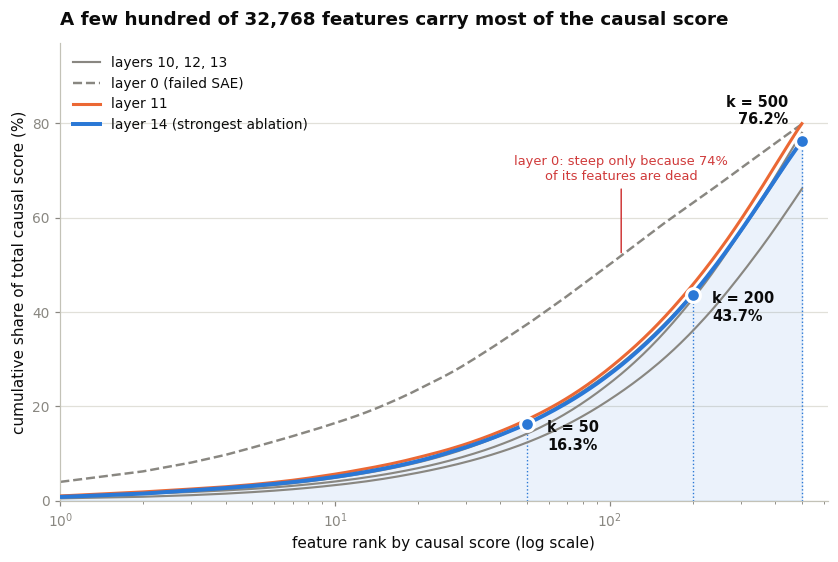

layer   top-50   top-200   top-500   nonzero features   top-500 mean activation
   0     37.4%    63.1%     79.9%               4485   0.0034
  10     14.2%    42.7%     78.0%              28264   0.0891
  11     17.2%    45.7%     79.9%              27810   0.1168
  12     12.3%    36.0%     66.1%              27298   0.1069
  13     16.4%    43.9%     76.5%              26649   0.1172
  14     16.3%    43.7%     76.2%              27918   0.1565

cross-check of the plotted curve against the stored fields:
  layer 11 top- 50  computed 0.1717   summary field 0.1717
  layer 11 top-200  computed 0.4573   summary field 0.4573
  layer 11 top-500  computed 0.7994   summary field 0.7994
  layer 14 top- 50  computed 0.1632   summary field 0.1632
  layer 14 top-200  computed 0.4369   summary field 0.4369
  layer 14 top-500  computed 0.7623   summary field 0.7623


In [6]:
# Layer 10 nests its causal stats one level deeper than the others.
stats_paths = {
    0: SAE / "sae_clevr_lite_layer0_attn_out_question_causal/causal_feature_stats.summary.json",
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_v2/causal_feature_stats.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/causal_feature_stats.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/causal_feature_stats.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/causal_feature_stats.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/causal_feature_stats.summary.json",
}

stats = {L: json.load(open(p)) for L, p in stats_paths.items()}
curves = {L: 100 * np.cumsum([f["causal_score"] for f in d["top_features"]]) / d["score_mass_total"]
          for L, d in stats.items()}
rank = np.arange(1, 501)

fig, ax = plt.subplots(figsize=(9, 5.4))

for L in (10, 12, 13):
    ax.plot(rank, curves[L], color=MUTED, lw=1.4, zorder=2,
            label="layers 10, 12, 13" if L == 10 else None)
ax.plot(rank, curves[0], color=MUTED, lw=1.6, ls="--", zorder=2, label="layer 0 (failed SAE)")
ax.plot(rank, curves[11], color=ORANGE, lw=2, zorder=3, label="layer 11")
ax.plot(rank, curves[14], color=BLUE, lw=2.6, zorder=4, label="layer 14 (strongest ablation)")
ax.fill_between(rank, 0, curves[14], color=BLUE, alpha=0.09, zorder=1)

for k, offset in [(50, (13, -17)), (200, (13, -17)), (500, (-9, 11))]:
    y = curves[14][k - 1]
    ax.plot(k, y, marker="o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=6)
    ax.annotate("k = %d\n%.1f%%" % (k, y), xy=(k, y), xytext=offset,
                textcoords="offset points", fontsize=9.5, fontweight="bold", color=INK,
                ha="right" if k == 500 else "left")
    ax.plot([k, k], [0, y], color=BLUE, lw=0.9, ls=":", zorder=1)

ax.annotate("layer 0: steep only because 74%\nof its features are dead", xy=(110, curves[0][109]),
            xytext=(110, 68), color=CRIT, fontsize=8.5, ha="center",
            arrowprops=dict(arrowstyle="-", color=CRIT, lw=1))

ax.set_xscale("log")
ax.set_xlim(1, 620)
ax.set_ylim(0, 97)
ax.set_xlabel("feature rank by causal score (log scale)")
ax.set_ylabel("cumulative share of total causal score (%)")
ax.set_title("A few hundred of 32,768 features carry most of the causal score", loc="left", pad=12)
ax.legend(loc="upper left")
tidy(ax)

fig.savefig(FIGDIR / "fig5_score_concentration.png")
plt.show()

print("layer   top-50   top-200   top-500   nonzero features   top-500 mean activation")
for L in (0, 10, 11, 12, 13, 14):
    d = stats[L]
    print("  %2d     %.1f%%    %.1f%%     %.1f%%   %16d   %.4f"
          % (L, 100 * d["score_mass_frac_top50"], 100 * d["score_mass_frac_top200"],
             100 * d["score_mass_frac_top500"], d["n_nonzero"],
             d["activation_mean_top_k"]["mean"]))
print()
print("cross-check of the plotted curve against the stored fields:")
for L in (11, 14):
    for k in (50, 200, 500):
        print("  layer %2d top-%3d  computed %.4f   summary field %.4f"
              % (L, k, curves[L][k - 1] / 100, stats[L]["score_mass_frac_top%d" % k]))

---

### Figure 6 — Distribution beats concentration

Spreading a fixed budget of 200 features over five layers (40 each) drops the margin 0.6182,
against 0.2131 for the same 200 concentrated at layer 11 — **2.90x** — and it beats a *four
times larger* concentrated budget (800 features, 0.1940) by **3.19x**. The concentrated count
curve is flat from k=40 and non-monotonic by k=800, so a single layer has a ceiling near 0.24
that no number of features breaks. Panel b rules out the obvious confound: the spread arm does
this while perturbing the residual stream **half** as much (0.0100 vs 0.0186), so the effect is
not bought with a larger intervention. Caveat: the budget conditions ran with a single control
set and therefore carry no z — their statistical support is the per-question Wilcoxon test
(p = 5.1e-35 for the spread arm), not a separation from control sets.

In [ ]:
ks = [40, 100, 200, 400, 800]
conc_drop = [drop(f"budget_concentrated_L11_k{k}") for k in ks]
conc_pert = [perturb(f"budget_concentrated_L11_k{k}") for k in ks]
spread_drop = drop("budget_spread40x5")
spread_pert = perturb("budget_spread40x5")
spread_k = cond("budget_spread40x5")["summary"]["total_features"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.24})

ax1.plot(ks, conc_drop, color=ORANGE, lw=2, marker="o", ms=7, zorder=3,
         label="concentrated at layer 11")
ax1.plot([spread_k], [spread_drop], color=BLUE, marker="D", ms=11, ls="none", zorder=4,
         mec=SURFACE, mew=2, label="spread: 40 features x 5 layers")

ax1.annotate("", xy=(spread_k, spread_drop), xytext=(spread_k, conc_drop[2]),
             arrowprops=dict(arrowstyle="<->", color=SECOND, lw=1.3))
ax1.text(spread_k * 1.08, (spread_drop + conc_drop[2]) / 2,
         "2.90x\nat equal budget", color=SECOND, fontsize=9.5, fontweight="bold", va="center")
ax1.annotate("3.19x the k=800 arm", xy=(800, conc_drop[4]), xytext=(210, 0.085),
             color=SECOND, fontsize=9, va="center",
             arrowprops=dict(arrowstyle="->", color=SECOND, lw=1))
ax1.text(spread_k / 1.14, spread_drop, "%.3f " % spread_drop, color=BLUE,
         fontsize=10, fontweight="bold", ha="right", va="center")
ax1.text(40, conc_drop[0] - 0.055, "flat from k=40: a single layer\nhas a ceiling near 0.24",
         color=ORANGE, fontsize=9, va="top")

ax1.set_xscale("log")
ax1.set_xticks(ks)
ax1.set_xticklabels([str(k) for k in ks])
ax1.set_xlim(32, 1150)
ax1.set_ylim(0, 0.72)
ax1.set_xlabel("total ablated features (log scale)")
ax1.set_ylabel("margin drop")
ax1.set_title("a. Effect against feature budget", loc="left")
ax1.legend(loc="upper right")
tidy(ax1)

# Panel b is the confound check: more effect cannot be explained by a bigger perturbation.
ax2.plot(conc_pert, conc_drop, color=ORANGE, lw=2, marker="o", ms=7, zorder=3,
         label="concentrated at layer 11")
for k, p, d in zip(ks, conc_pert, conc_drop):
    ax2.text(p, d - 0.028, "k=%d" % k, color=ORANGE, fontsize=8.5, ha="center")
ax2.plot([spread_pert], [spread_drop], color=BLUE, marker="D", ms=11, ls="none", zorder=4,
         mec=SURFACE, mew=2, label="spread: 40 features x 5 layers")
ax2.text(spread_pert + 0.0012, spread_drop, " 200 features,\n half the perturbation",
         color=BLUE, fontsize=9, va="center")

ax2.set_xlim(0.005, 0.037)
ax2.set_ylim(0, 0.72)
ax2.set_xlabel("mean relative perturbation of the residual stream")
ax2.set_ylabel("margin drop")
ax2.set_title("b. Effect against perturbation size", loc="left")
ax2.legend(loc="lower right")
tidy(ax2)

fig.savefig(FIGDIR / "fig6_budget_distribution.png")
plt.show()

print("spread %.4f / concentrated-200 %.4f = %.2fx ; / concentrated-800 %.4f = %.2fx"
      % (spread_drop, conc_drop[2], spread_drop / conc_drop[2],
         conc_drop[4], spread_drop / conc_drop[4]))

---

### Figure 7 — Cross-layer redundancy does not explain the single-layer shortfall

If single-layer ablation falls short because downstream layers re-read the image, then blocking
every downstream layer should make the same ablation bite harder. Panel a is that direct test:
at layer 14 the measured combination (0.5989) exceeds the additive prediction by **+0.0024** —
0.2%, i.e. with all downstream re-reading blocked the ablation does the work it always did.
Layer 11 shows real but modest synergy (+0.0828, 39% amplification), nowhere near the ~2x that
closing its gap would require. Panel b is the leave-one-out cross-check and it points the wrong
way for redundancy at three of five layers: removing layer 12 from the span costs 0.2991,
**1.79x** its standalone 0.1670 — those layers matter *more* in context, not less. Caveats: the
standalone values for layers 10, 12 and 13 (marked `*`) come from the published single-layer runs
rather than this harness, so panel b is a cross-run join — legitimate, because the binding arm
does not depend on the control regime and the A0 regression reproduces the layer-11 number to
7.7e-06, but worth stating. The knockout arm is `Image->Question` throughout.

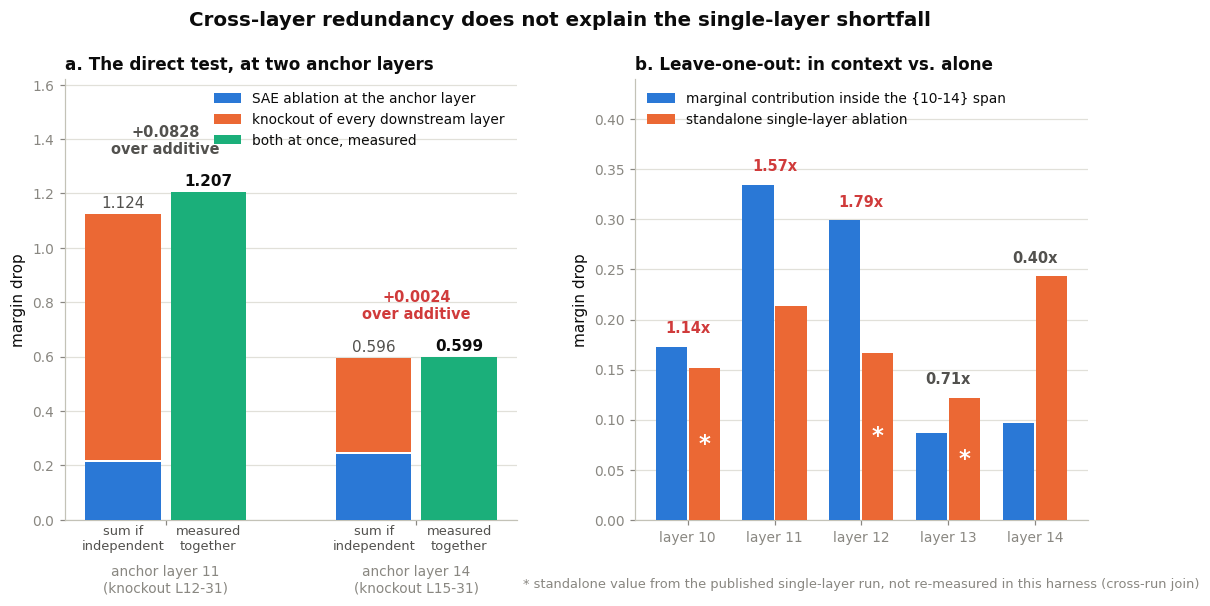

L11  ablation 0.2131 + downstream knockout 0.9110 = 1.1241 predicted, 1.2068 measured (+0.0828)
L14  ablation 0.2432 + downstream knockout 0.3533 = 0.5964 predicted, 0.5989 measured (+0.0024)


In [8]:
anchors = [11, 14]
ko_names = {11: "downstream_knockout_L12-31", 14: "downstream_knockout_L15-31"}
abl = [drop(f"downstream_ablate_L{L}") for L in anchors]
ko = [drop(ko_names[L]) for L in anchors]
comb = [drop(f"downstream_combined_L{L}") for L in anchors]
predicted = [a + k for a, k in zip(abl, ko)]

# Panel b joins this run's marginals to the published single-layer drops for 10, 12 and 13.
ablation_paths = {
    10: SAE / "sae_clevr_lite_layer10_attn_out_question_causal/results/ablation_results.summary.json",
    11: SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json",
    12: SAE / "sae_clevr_lite_layer12_attn_out_question_causal/results/ablation_v2_results.summary.json",
    13: SAE / "sae_clevr_lite_layer13_attn_out_question_causal/results/ablation_v2_results.summary.json",
    14: SAE / "sae_clevr_lite_layer14_attn_out_question_causal/results/ablation_v2_results.summary.json",
}
published = {L: json.load(open(p))["significance"]["mean_margin_drop"]["binding"]
             for L, p in ablation_paths.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"wspace": 0.26})

x = np.arange(len(anchors))
w = 0.3
GAP = 0.006  # surface gap between the stacked segments, so they do not read as one block

for i in range(len(anchors)):
    ax1.bar(x[i] - w / 2 - 0.02, abl[i], width=w, color=BLUE, zorder=3,
            label="SAE ablation at the anchor layer" if i == 0 else None)
    ax1.bar(x[i] - w / 2 - 0.02, ko[i] - GAP, width=w, bottom=abl[i] + GAP, color=ORANGE, zorder=3,
            label="knockout of every downstream layer" if i == 0 else None)
    ax1.bar(x[i] + w / 2 + 0.02, comb[i], width=w, color=AQUA, zorder=3,
            label="both at once, measured" if i == 0 else None)
    ax1.text(x[i] + w / 2 + 0.02, comb[i] + 0.022, "%.3f" % comb[i], color=INK,
             fontsize=10, fontweight="bold", ha="center")
    ax1.text(x[i] - w / 2 - 0.02, predicted[i] + 0.022, "%.3f" % predicted[i], color=SECOND,
             fontsize=10, ha="center")
    ax1.annotate("%+.4f\nover additive" % (comb[i] - predicted[i]),
                 xy=(x[i], max(comb[i], predicted[i]) + 0.14),
                 color=CRIT if i == 1 else SECOND, fontsize=9.5, fontweight="bold", ha="center")

ax1.set_xticks(x)
ax1.set_xticklabels(["anchor layer 11\n(knockout L12-31)", "anchor layer 14\n(knockout L15-31)"])
ax1.tick_params(axis="x", which="major", pad=26)
# A second tick level names the bars, so the stack reads as a prediction rather than a total.
ax1.set_xticks([xi + off for xi in x for off in (-w / 2 - 0.02, w / 2 + 0.02)], minor=True)
ax1.set_xticklabels(["sum if\nindependent", "measured\ntogether"] * 2, minor=True,
                    fontsize=8.5, color=SECOND)
ax1.tick_params(axis="x", which="minor", length=0)
ax1.set_ylim(0, 1.62)
ax1.set_ylabel("margin drop")
ax1.set_title("a. The direct test, at two anchor layers", loc="left", fontsize=11)
ax1.legend(loc="upper right")
tidy(ax1)

loo = {r["layer"]: r for r in ANALYSIS["leave_one_out"]}
layers = [10, 11, 12, 13, 14]
marginal = [loo[L]["marginal"] for L in layers]
standalone = [loo[L]["standalone"] if loo[L]["standalone"] is not None else published[L]
              for L in layers]
joined = [loo[L]["standalone"] is None for L in layers]

x = np.arange(len(layers))
w = 0.36
ax2.bar(x - w / 2 - 0.01, marginal, width=w, color=BLUE, zorder=3,
        label="marginal contribution inside the {10-14} span")
ax2.bar(x + w / 2 + 0.01, standalone, width=w, color=ORANGE, zorder=3,
        label="standalone single-layer ablation")

for xi, m, s, j in zip(x, marginal, standalone, joined):
    ax2.text(xi, max(m, s) + 0.014, "%.2fx" % (m / s), ha="center",
             color=CRIT if m / s > 1 else SECOND, fontsize=9.5, fontweight="bold")
    if j:
        ax2.text(xi + w / 2 + 0.01, s / 2, "*", ha="center", va="center", color=SURFACE,
                 fontsize=15, fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(["layer %d" % L for L in layers])
ax2.set_ylim(0, 0.44)
ax2.set_ylabel("margin drop")
ax2.set_title("b. Leave-one-out: in context vs. alone", loc="left", fontsize=11)
ax2.legend(loc="upper left")
ax2.text(0.5, -0.155, "* standalone value from the published single-layer run, not re-measured "
         "in this harness (cross-run join)",
         transform=ax2.transAxes, ha="center", color=MUTED, fontsize=8.5)
tidy(ax2)

fig.suptitle("Cross-layer redundancy does not explain the single-layer shortfall",
             fontsize=13, fontweight="bold", y=1.0)
fig.savefig(FIGDIR / "fig7_redundancy_falsified.png")
plt.show()

for L, a, k, c, p in zip(anchors, abl, ko, comb, predicted):
    print("L%-3d ablation %.4f + downstream knockout %.4f = %.4f predicted, %.4f measured (%+.4f)"
          % (L, a, k, p, c, c - p))

---

### Figure 8a — Ablation against the knockout ceiling

One point per condition: ablation drop `A` against knockout drop `K`, measured on the same 256
questions. All nine conditions fall **below parity** — that gap is the ceiling — and cluster around
a single line through the origin at the pooled recovery of **72.6%**, which is the "ablation follows
the pathway knockout severs" claim in one mark type. In aggregate the two curves grow at 0.193 and
0.269 per layer, **ratio 0.718**.

Marker area increases with span size. A span-size effect would show as large and small markers
splitting either side of the fit; they do not, which is the no-trend result seen without taking a
ratio. The faint path linking the nested spans runs *backwards* in x from span 1 to span 2 because
adding inhibitory layer 13 lowers the ceiling.

Open squares are the compositions outside the nested chain: layer 11 alone, the two non-nested
three-layer spans, and the layer-13 sensitivity span.

In [ ]:
# Both span figures read every number from analysis/multilayer_summary.json; nothing is
# recomputed here. Sized so the smallest text prints at ~8 pt against the paper's 11 pt body.
trend = ANALYSIS["redundancy_trend"]
by_span = {r["label"]: r for r in ANALYSIS["redundancy_by_span"] if r.get("status") == "ok"}
nested = [by_span[k] for k in ("{14}", "{13,14}", "{12,13,14}", "{11-14}", "{10-14}")]
other = [by_span[k] for k in ("{11}", "{10,11,12}", "{10,12,14}", "{10,11,12,14}")]
PAPER_RC = {"font.size": 9, "axes.labelsize": 9, "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5, "legend.fontsize": 8.5}

# A ratio read off the vertical gap between two curves is unreadable; as a slope it is not.
# Every condition below parity is the ceiling, and one line through all nine is the
# proportionality claim. Marker area carries span size, so a span-size effect would show as
# large and small markers splitting either side of the fit. They do not.
with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(3.9, 3.7))
    LIM = 1.52

    ax.plot([0, LIM], [0, LIM], color=BASELINE, lw=1, ls=(0, (4, 3)), zorder=1)
    ax.text(1.31, 1.35, "parity", color=MUTED, fontsize=8.5, rotation=40,
            rotation_mode="anchor", ha="center", va="center")
    ax.plot([0, LIM], [0, LIM * trend["pooled_ratio"]], color=BLUE, lw=1.3, zorder=2)
    ax.text(1.50, 1.13, "pooled %.1f%%" % (100 * trend["pooled_ratio"]), color=BLUE,
            fontsize=8.5, fontweight="bold", ha="right", va="bottom")

    # Runs backwards in x from span 1 to span 2: adding inhibitory layer 13 lowers K.
    ax.plot([r["knockout_mean"] for r in nested], [r["ablation_mean"] for r in nested],
            color=BLUE, lw=0.9, alpha=0.4, zorder=3)
    for r in nested:
        ax.plot(r["knockout_mean"], r["ablation_mean"], "o", ms=4 + 1.4 * r["span_size"],
                color=BLUE, mec=SURFACE, mew=0.7, zorder=5,
                label="nested spans" if r["span_size"] == 5 else None)
    for i, r in enumerate(other):
        ax.plot(r["knockout_mean"], r["ablation_mean"], "s", ms=5.5, mfc=SURFACE,
                mec=ORANGE, mew=1.4, zorder=5, label="other spans" if i == 0 else None)

    ax.set_xlim(0, LIM); ax.set_ylim(0, LIM); ax.set_aspect("equal")
    ax.set_xticks([0, 0.5, 1.0, 1.5]); ax.set_yticks([0, 0.5, 1.0, 1.5])
    ax.set_xlabel("knockout drop $K$")
    ax.set_ylabel("ablation drop $A$")
    ax.legend(loc="upper left", handletextpad=0.3, borderpad=0.15, labelspacing=0.3)
    tidy(ax)

    fig.savefig(FIGDIR / "fig8a_ablation_vs_knockout.png", dpi=300)
    plt.show()

print("condition            A        K        R")
for r in nested + other:
    print("  %-15s %.4f   %.4f   %5.1f%%" % (r["label"], r["ablation_mean"],
                                             r["knockout_mean"], 100 * r["ratio"]))
print("\npooled slope through the origin: %.1f%% (95%% CI %.1f - %.1f)"
      % (100 * trend["pooled_ratio"], 100 * trend["pooled_ci_low"], 100 * trend["pooled_ci_high"]))
print("aggregate growth: ablation %.3f/layer, knockout %.3f/layer, ratio %.4f"
      % (ANALYSIS["saturation"]["ablation_fit"]["initial_slope"],
         ANALYSIS["saturation"]["knockout_fit"]["initial_slope"],
         ANALYSIS["saturation"]["slope_ratio"]))


---

### Figure 8b — Recovered share against span size

`R = A/K` per span with paired bootstrap intervals (one resample of the 256 questions applied to
both arms and every span at once, seed 42).

**R is not a fixed share.** The per-span ratios run 65.1–87.5% across the nested spans with **no
value inside all five intervals** (highest lower bound 81.5% against lowest upper bound 68.5%);
spread 22.5 points, 95% CI 17.7–28.4. Earlier drafts called this a "constant ~72%" — that was the
aggregate slope ratio from 8a promoted into a per-span claim it does not support.

**What survives is the direction.** R shows no trend with span size: slope **−0.010 per layer, 95%
CI [−0.024, +0.003]**, containing zero. A redundancy account needs R to *rise* as the span covers
more of the layers said to be compensating. It does not.

Open squares sit at their true span size, so the composition effect is a vertical comparison: at
three layers R runs 58.5% / 73.6% / 87.5%, at one layer 49.9% against 67.7%. The ringed point is
span 2, where layer 13 enters and lowers K from 0.359 to 0.319 — R climbs with no gain in what the
features recover. The trend line and pooled band describe the nested spans only.

In [ ]:
# Both span figures read every number from analysis/multilayer_summary.json; nothing is
# recomputed here. Sized so the smallest text prints at ~8 pt against the paper's 11 pt body.
trend = ANALYSIS["redundancy_trend"]
by_span = {r["label"]: r for r in ANALYSIS["redundancy_by_span"] if r.get("status") == "ok"}
nested = [by_span[k] for k in ("{14}", "{13,14}", "{12,13,14}", "{11-14}", "{10-14}")]
other = [by_span[k] for k in ("{11}", "{10,11,12}", "{10,12,14}", "{10,11,12,14}")]
PAPER_RC = {"font.size": 9, "axes.labelsize": 9, "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5, "legend.fontsize": 8.5}

# Equal span size, different composition, different R -- so the non-nested and sensitivity
# conditions sit at their true span size rather than jittered around one x position.
pooled = 100 * trend["pooled_ratio"]

with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(4.4, 2.9))

    ax.axhspan(100 * trend["pooled_ci_low"], 100 * trend["pooled_ci_high"],
               color=BLUE, alpha=0.10, lw=0, zorder=1)
    ax.axhline(pooled, color=BLUE, lw=1, ls="--", zorder=2)
    grid_x = np.array([1, 5], float)
    ax.plot(grid_x, pooled + trend["slope_per_layer"] * 100 * (grid_x - 3),
            color=SECOND, lw=1.3, zorder=3)

    def bars(row, x, **kw):
        ax.errorbar(x, 100 * row["ratio"],
                    yerr=[[100 * (row["ratio"] - row["ci_low"])],
                          [100 * (row["ci_high"] - row["ratio"])]],
                    capsize=2.5, capthick=1.1, **kw)

    for r in nested:
        bars(r, r["span_size"] - (0.15 if r["span_size"] in (1, 3, 4) else 0),
             fmt="o", ms=4.5, color=BLUE, ecolor=BLUE, elinewidth=1.4, zorder=5,
             label="nested spans" if r["span_size"] == 5 else None)
    for r, dx in zip(other, (0.15, 0.0, 0.17, 0.15)):
        bars(r, r["span_size"] + dx, fmt="s", ms=4, mfc=SURFACE, mec=ORANGE, mew=1.3,
             ecolor=ORANGE, elinewidth=1.2, zorder=4,
             label="other spans" if r["label"] == "{11}" else None)

    # Span 2 is where inhibitory layer 13 enters and lowers K, so R climbs without any gain
    # in what the features recover. Ringed rather than labelled: no text block fits between
    # the span-2 and span-3 whiskers at legible size, and the caption carries it.
    ax.plot(2, 100 * nested[1]["ratio"], "o", ms=11, mfc="none", mec=CRIT, mew=1.3, zorder=6)

    ax.set_xlim(0.62, 5.35); ax.set_ylim(43, 97); ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("span size (layers)")
    ax.set_ylabel("$R = A/K$   (%)")
    ax.legend(loc="lower right", handletextpad=0.3, borderpad=0.2, labelspacing=0.3)
    tidy(ax)

    fig.savefig(FIGDIR / "fig8b_recovered_share.png", dpi=300)
    plt.show()

print(trend["interpretation"])
print()
print("spread %.1f%% (95%% CI %.1f - %.1f);  highest lower bound %.1f%% vs lowest upper bound %.1f%%"
      % (100 * trend["spread"], 100 * trend["spread_ci_low"], 100 * trend["spread_ci_high"],
         100 * trend["highest_ci_low"], 100 * trend["lowest_ci_high"]))
print()
for r in nested + other:
    print("  %-12s size %d  R %5.1f%%  [%.1f, %.1f]"
          % (r["label"], r["span_size"], 100 * r["ratio"], 100 * r["ci_low"], 100 * r["ci_high"]))


---

### Figure 9 — The control-regime correction

This is the repair for the caveat that governs figure 2. Same layer, same 200 features, same
intervention — only the random control changed. Uniform controls (every published run) are drawn
from all 32,768 features, which are overwhelmingly near-dead: they land at -0.0004 and barely
touch the stream (relative perturbation 0.0019). Matched controls, sampled on `activation_mean`
with `strict_matching: true`, land at -0.0217 and perturb the stream **harder than the causal
features themselves** (0.0226 vs 0.0186) while still producing a tenth of the effect. z falls from
**81.6 to 63.5**. The binding arm is untouched at 0.2131, so the margin drops and positive
fractions in figures 2, 3 and 5 stand as reported — it is only the z-scores that need restating.
Two caveats: both z values are estimated from 15 control draws and carry a standard error of order
12, so this is a correction of scale rather than a precise pair of numbers (the per-question
Wilcoxon test, p = 2.2e-35, is the one with power); and only layer 11 has a matched number so far,
leaving the rest of the per-layer table on the uniform standard.

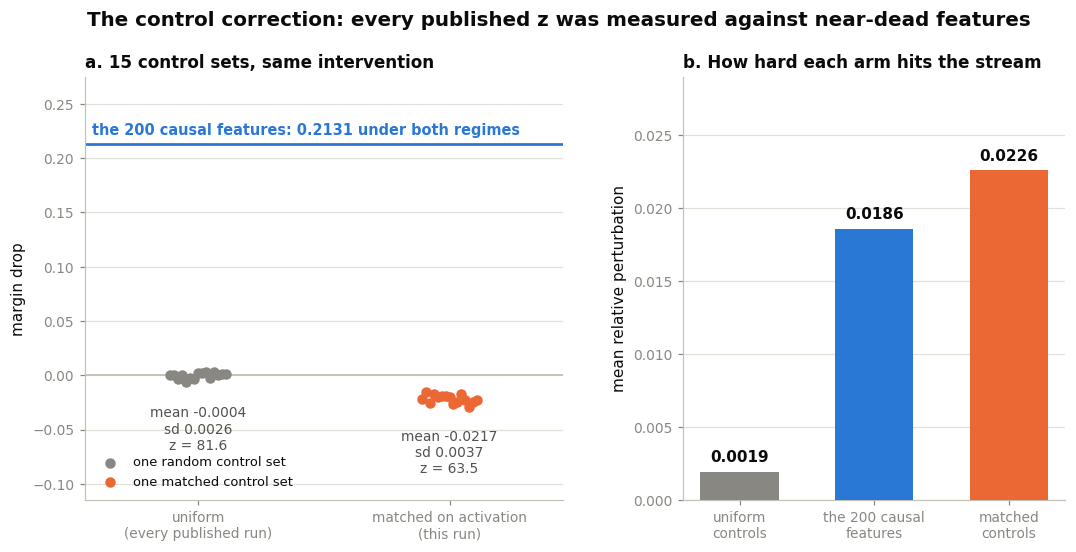

uniform  z=81.6  control mean -0.0004  perturbation 0.0019
matched  z=63.5  control mean -0.0217  perturbation 0.0226
binding  drop 0.2131  perturbation 0.0186 (unchanged by the control regime)


In [10]:
pub11 = json.load(open(
    SAE / "sae_clevr_lite_layer11_attn_out_question_causal/results/ablation_results.summary.json"))
uni_drop = [s["mean_margin_drop"] for s in pub11["random_set_summaries"]]
uni_pert = [s["mean_relative_perturbation"] for s in pub11["random_set_summaries"]]
uni_z = pub11["significance"]["mean_margin_drop"]["z_score"]
bind_drop = pub11["significance"]["mean_margin_drop"]["binding"]
bind_pert = pub11["binding_results"]["field_summaries"]["perturb_relative_norm"]["mean"]

a0 = cond("A0_regression_L11")
mat_drop = [s["mean_margin_drop"] for s in a0["control_summaries"]]
mat_pert = [s["mean_relative_perturbation"] for s in a0["control_summaries"]]
mat_z = [r for r in ANALYSIS["significance"]
         if r["condition_id"] == "A0_regression_L11"][0]["z_score"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5),
                               gridspec_kw={"width_ratios": [1.25, 1], "wspace": 0.28})

jitter = np.linspace(-0.11, 0.11, 15)
ax1.axhline(bind_drop, color=BLUE, lw=1.8, zorder=2)
ax1.text(-0.42, bind_drop + 0.006, "the 200 causal features: %.4f under both regimes" % bind_drop,
         color=BLUE, fontsize=9.5, fontweight="bold", va="bottom")
ax1.axhline(0, color=BASELINE, lw=1.2, zorder=1)

ax1.scatter(0 + jitter, uni_drop, s=34, color=MUTED, zorder=3, label="one random control set")
ax1.scatter(1 + jitter, mat_drop, s=34, color=ORANGE, zorder=3, label="one matched control set")
for xi, vals, z in [(0, uni_drop, uni_z), (1, mat_drop, mat_z)]:
    ax1.text(xi, np.mean(vals) - 0.028, "mean %.4f\nsd %.4f\nz = %.1f"
             % (np.mean(vals), np.std(vals), z),
             color=SECOND, fontsize=9, ha="center", va="top")

ax1.set_xticks([0, 1])
ax1.set_xticklabels(["uniform\n(every published run)", "matched on activation\n(this run)"])
ax1.set_xlim(-0.45, 1.45)
ax1.set_ylim(-0.115, 0.275)
ax1.set_ylabel("margin drop")
ax1.set_title("a. 15 control sets, same intervention", loc="left", fontsize=11)
ax1.legend(loc="lower left", fontsize=8.5)
tidy(ax1)

bars = [("uniform\ncontrols", np.mean(uni_pert), MUTED),
        ("the 200 causal\nfeatures", bind_pert, BLUE),
        ("matched\ncontrols", np.mean(mat_pert), ORANGE)]
xs = np.arange(3)
ax2.bar(xs, [b[1] for b in bars], width=0.58, color=[b[2] for b in bars], zorder=3)
for xi, (_, v, _c) in zip(xs, bars):
    ax2.text(xi, v + 0.0007, "%.4f" % v, ha="center", color=INK, fontsize=10, fontweight="bold")

ax2.set_xticks(xs)
ax2.set_xticklabels([b[0] for b in bars])
ax2.set_ylim(0, 0.029)
ax2.set_ylabel("mean relative perturbation")
ax2.set_title("b. How hard each arm hits the stream", loc="left", fontsize=11)
tidy(ax2)

fig.suptitle("The control correction: every published z was measured against near-dead features",
             fontsize=13, fontweight="bold", y=1.0)
fig.savefig(FIGDIR / "fig9_control_regime.png")
plt.show()

print("uniform  z=%.1f  control mean %+.4f  perturbation %.4f" % (uni_z, np.mean(uni_drop), np.mean(uni_pert)))
print("matched  z=%.1f  control mean %+.4f  perturbation %.4f" % (mat_z, np.mean(mat_drop), np.mean(mat_pert)))
print("binding  drop %.4f  perturbation %.4f (unchanged by the control regime)" % (bind_drop, bind_pert))